In [1]:
import torch
from torch import nn
from torch.optim import Adam
import librosa
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import time
from skimage.transform import resize

device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

In [5]:
df = pd.read_csv('/Users/mclight/Desktop/Quran Classification/files_paths.csv')
print(df.head())
print('Name of Reciters:', df['Class'].unique())
print('Number of Reciters:', len(df['Class'].unique()))

                                        FilePath               Class
0  ./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav  Mohammed_Aluhaidan
1  ./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav  Mohammed_Aluhaidan
2  ./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav  Mohammed_Aluhaidan
3  ./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav  Mohammed_Aluhaidan
4  ./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav  Mohammed_Aluhaidan
Name of Reciters: ['Mohammed_Aluhaidan' 'Yasser_Aldossary' 'Maher_Almuaiqly'
 'Nasser_Alqutami' 'AbdulBari_Althubaity' 'Bander_Balilah'
 'Ali_Alhothaify' 'Saud_Alshuraim' 'Mohammed_Ayoub' 'AbdulRahman_Alsudais'
 'Saad_Alghamdi' 'Abdullah_Albuaijan']
Number of Reciters: 12


In [6]:
df['FilePath'] = '/Users/mclight/Desktop/Quran Classification/Dataset' + df['FilePath'].str[1:]
df.head()

,FilePath,Class
0,/Users/mclight/Desktop/Quran Classification/Da...,Mohammed_Aluhaidan
1,/Users/mclight/Desktop/Quran Classification/Da...,Mohammed_Aluhaidan
2,/Users/mclight/Desktop/Quran Classification/Da...,Mohammed_Aluhaidan
3,/Users/mclight/Desktop/Quran Classification/Da...,Mohammed_Aluhaidan
4,/Users/mclight/Desktop/Quran Classification/Da...,Mohammed_Aluhaidan


In [7]:
df['FilePath'].iloc[2]

'/Users/mclight/Desktop/Quran Classification/Dataset/Dataset/Mohammed_Aluhaidan/lohaidan_401.wav'

Data shape: (6687, 2)
Class Distribution:
 Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Maher_Almuaiqly         576
Bander_Balilah          576
Ali_Alhothaify          576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64


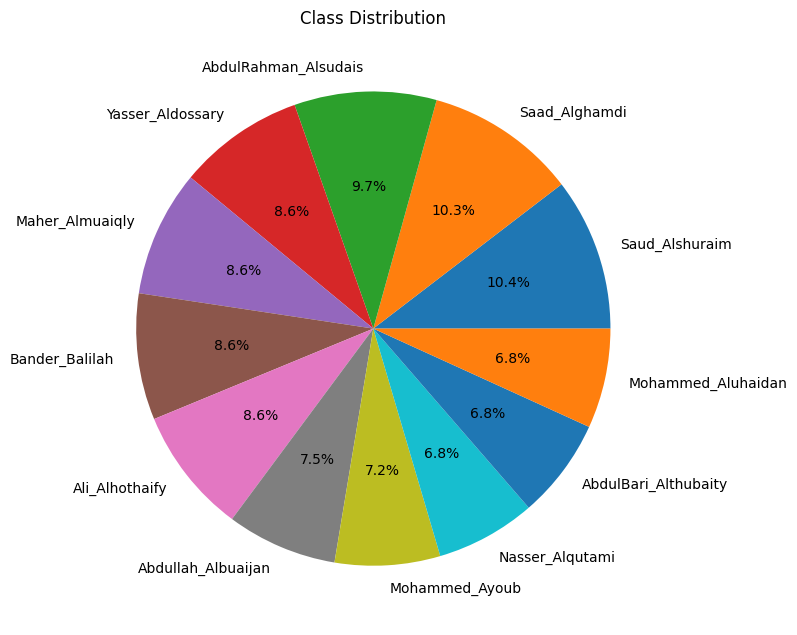

In [11]:
class_counts = df['Class'].value_counts()

print('Data shape:', df.shape)
print('Class Distribution:\n', class_counts)

plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

In [18]:
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])

train = df.sample(frac=0.7, random_state=7)
test = df.drop(train.index)
val = test.sample(frac=0.5, random_state=7)

print('Train shape: ', train.shape)
print('Test shape: ', test.shape)
print('Val shape: ', val.shape)

Train shape:  (4681, 2)
Test shape:  (2006, 2)
Val shape:  (1003, 2)


In [24]:
class CustomAudioDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe
        self.labels = torch.Tensor((list(dataframe['Class']))).type(torch.LongTensor).to(device)
        self.audios = [torch.Tensor(self.get_spectrogram(path)).type(torch.FloatTensor).to(device) for path in dataframe['FilePath']]
    
    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]
        label = torch.Tensor(self.labels[idx]).to(device)
        audio = self.audios[idx].unsqueeze(0).to(device)
        return audio, label
    
    def get_spectrogram(self, file_path):
        sr=22050
        duration = 5
        
        img_height = 128
        img_width = 256
        
        signal, sr = librosa.load(file_path, sr=sr, duration=duration)
        
        spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        spec_resized = librosa.util.fix_length(spec_db, size=(duration*sr)//512+1)
        spec_resized= resize(spec_resized, (img_height, img_width), anti_aliasing=True)
        return spec_resized

In [25]:
train_ds = CustomAudioDataset(dataframe=train)
test_ds = CustomAudioDataset(dataframe=test)
val_ds = CustomAudioDataset(dataframe=val)

In [26]:
LR = 1e-04
BATCH_SIZE = 16
EPOCHS = 25

In [27]:
trainLD = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
testLD = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)
valLD = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [30]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pooling = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(32768, 4096)
        self.linear2 = nn.Linear(4096, 1024)
        self.linear3 = nn.Linear(1024, 512)
        self.output = nn.Linear(512, len(df['Class'].unique()))

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pooling(x)
        x = self.relu(self.conv2(x))
        x = self.pooling(x)
        x = self.relu(self.conv3(x))
        x = self.pooling(x)

        x = self.flatten(x)

        x = self.relu(self.linear1(x))
        x = self.dropout(x)
        x = self.relu(self.linear2(x))
        x = self.dropout(x)
        x = self.relu(self.linear3(x))
        x = self.dropout(x)

        x = self.output(x)
        return x

In [31]:
model = Net().to(device)
print(model)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [33]:
from torchsummary import summary
model.to('cpu')
summary(model, (1,128,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
              ReLU-2         [-1, 16, 128, 256]               0
         MaxPool2d-3          [-1, 16, 64, 128]               0
            Conv2d-4          [-1, 32, 64, 128]           4,640
              ReLU-5          [-1, 32, 64, 128]               0
         MaxPool2d-6           [-1, 32, 32, 64]               0
            Conv2d-7           [-1, 64, 32, 64]          18,496
              ReLU-8           [-1, 64, 32, 64]               0
         MaxPool2d-9           [-1, 64, 16, 32]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                 [-1, 4096]     134,221,824
             ReLU-12                 [-1, 4096]               0
          Dropout-13                 [-1, 4096]               0
           Linear-14                 [-

In [35]:
model.to(device)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [36]:
criterion = nn.CrossEntropyLoss()
optim = Adam(model.parameters(), lr=LR)

In [39]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

start_time = time.time()

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_loss_val = 0
    total_acc_val = 0

    model.train()
    for inputs, labels in trainLD:
        optim.zero_grad()
        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()
        train_loss.backward()
        optim.step()

        train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        total_acc_train += train_acc

    model.eval()
    with torch.no_grad():
        for inputs, labels in valLD:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            total_acc_val += val_acc

    avg_train_loss = round(total_loss_train / len(trainLD), 4)
    avg_val_loss   = round(total_loss_val / len(valLD), 4)
    avg_train_acc  = round(total_acc_train / len(train_ds) * 100, 4)
    avg_val_acc    = round(total_acc_val / len(val_ds) * 100, 4)

    total_loss_train_plot.append(avg_train_loss)
    total_loss_val_plot.append(avg_val_loss)
    total_acc_train_plot.append(avg_train_acc)
    total_acc_val_plot.append(avg_val_acc)

    print(f'Epoch: {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss} | Train Acc: {avg_train_acc}% | Val Loss: {avg_val_loss} | Val Acc: {avg_val_acc}%')
    print('=' * 50)

print('Training Time:', round(time.time() - start_time, 4), 'seconds')

Epoch: 1/25 | Train Loss: 0.9677 | Train Acc: 66.9301% | Val Loss: 0.3102 | Val Acc: 89.7308%
Epoch: 2/25 | Train Loss: 0.3305 | Train Acc: 89.6817% | Val Loss: 0.1352 | Val Acc: 95.9123%
Epoch: 3/25 | Train Loss: 0.1561 | Train Acc: 95.5565% | Val Loss: 0.0647 | Val Acc: 98.6042%
Epoch: 4/25 | Train Loss: 0.1 | Train Acc: 97.2015% | Val Loss: 0.0432 | Val Acc: 98.6042%
Epoch: 5/25 | Train Loss: 0.0615 | Train Acc: 98.3551% | Val Loss: 0.0333 | Val Acc: 99.1027%
Epoch: 6/25 | Train Loss: 0.04 | Train Acc: 98.8678% | Val Loss: 0.051 | Val Acc: 98.6042%
Epoch: 7/25 | Train Loss: 0.0518 | Train Acc: 98.4405% | Val Loss: 0.0554 | Val Acc: 98.5045%
Epoch: 8/25 | Train Loss: 0.0293 | Train Acc: 99.1455% | Val Loss: 0.0643 | Val Acc: 98.3051%
Epoch: 9/25 | Train Loss: 0.0273 | Train Acc: 99.1668% | Val Loss: 0.0411 | Val Acc: 98.7039%
Epoch: 10/25 | Train Loss: 0.038 | Train Acc: 98.9105% | Val Loss: 0.084 | Val Acc: 97.6072%
Epoch: 11/25 | Train Loss: 0.0282 | Train Acc: 99.1455% | Val Loss:

In [41]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for input, labels in testLD:
        prediction = model(input)
        acc = (torch.argmax(prediction, axis=1) == labels).sum().item()

        total_acc_test += acc
    print(f'Total Acc Score is: ', round((total_acc_test/test_ds.__len__() * 100), 4))

Total Acc Score is:  98.9033


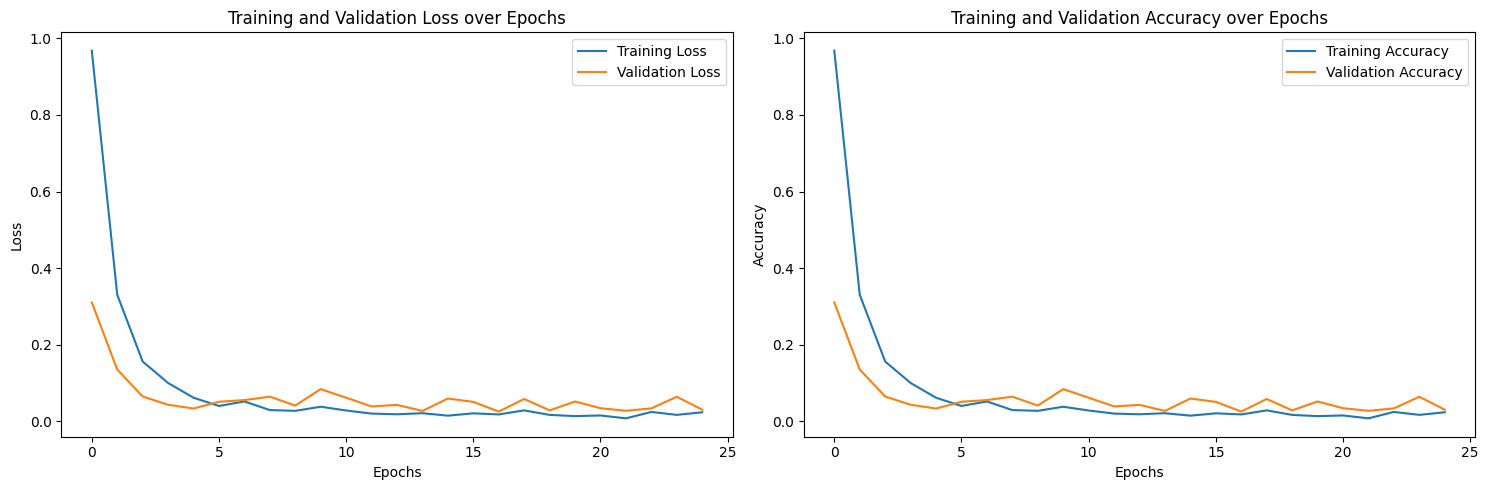

In [43]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_loss_train_plot, label='Training Accuracy')
axs[1].plot(total_loss_val_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.tight_layout()